# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2

2026-09-10 23:06:01.190894: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-10 23:06:02.188953: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-10 23:06:02.189229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-10 23:06:02.405847: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-10 23:06:02.786942: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-10 23:06:02.790648: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
# Cargar el dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (50000, 32, 32, 3)
Tamaño de y_train: (50000, 1)
Tamaño de X_test: (10000, 32, 32, 3)
Tamaño de y_test: (10000, 1)


In [4]:
# Normalizar los valores de los píxeles entre 0 y 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Mínimo:", X_train.min())
print("Máximo:", X_train.max())

Mínimo: 0.0
Máximo: 1.0


In [5]:
# Convertir las etiquetas a formato one-hot
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de y_train: (50000, 10)
Forma de y_test: (10000, 10)


## Definiciones de modelos

### MODELO CNN 1

In [6]:
modelo_1 = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation="softmax")
])

2026-09-10 23:06:19.288036: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-10 23:06:19.289584: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### MODELO CNN 2

In [7]:
modelo_2 = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation="softmax")
])

In [8]:
modelo_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 64)                2

In [9]:
modelo_2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 64)       

 chNormalization)                                                
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 4, 4, 128)         0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               262272    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 403882 (1.54 MB)
Trainable params: 403434 (1.54 MB)
Non-trainable params: 448 (1.75 KB)
________________________________________

In [10]:
# Data Augmentation
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1)
])

## Entrenamiento de modelos.

### MODELO 1

In [11]:
# Crear el dataset de entrenamiento
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Aplicar Data Augmentation
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Crear lotes
train_dataset = train_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

print("Dataset de entrenamiento preparado.")

2026-09-10 23:06:29.200335: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Dataset de entrenamiento preparado.


In [12]:
# Compilar CNN 1
modelo_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN 1 compilada correctamente.")

CNN 1 compilada correctamente.


In [13]:
# Entrenar CNN 1
historial_1 = modelo_1.fit(
    train_dataset,
    epochs=5,
    validation_data=(X_test, y_test)
)

2026-09-10 23:06:43.820937: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/5
  2/782 [..............................] - ETA: 1:07 - loss: 2.2824 - accuracy: 0.1172 

2026-09-10 23:06:46.981545: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21528576 exceeds 10% of free system memory.
2026-09-10 23:06:46.985988: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21528576 exceeds 10% of free system memory.
2026-09-10 23:06:47.077883: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 21528576 exceeds 10% of free system memory.


782/782 [==============================] - 66s 83ms/step - loss: 1.8357 - accuracy: 0.3221 - val_loss: 1.4859 - val_accuracy: 0.4502
Epoch 2/5
782/782 [==============================] - 62s 79ms/step - loss: 1.6109 - accuracy: 0.4136 - val_loss: 1.3366 - val_accuracy: 0.5115
Epoch 3/5
782/782 [==============================] - 64s 81ms/step - loss: 1.5393 - accuracy: 0.4400 - val_loss: 1.3228 - val_accuracy: 0.5190
Epoch 4/5
782/782 [==============================] - 66s 84ms/step - loss: 1.4773 - accuracy: 0.4647 - val_loss: 1.2462 - val_accuracy: 0.5406
Epoch 5/5
782/782 [==============================] - 64s 82ms/step - loss: 1.4376 - accuracy: 0.4774 - val_loss: 1.1848 - val_accuracy: 0.5756


### MODELO 2

In [14]:
# Compilar CNN 2
modelo_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN 2 compilada correctamente.")

CNN 2 compilada correctamente.


In [15]:
# Generador de imágenes con Data Augmentation
generador = keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

print("Generador de Data Augmentation preparado.")

Generador de Data Augmentation preparado.


In [16]:
train_generator = generador.flow(
    X_train,
    y_train,
    batch_size=16,
    shuffle=True
)

print("Generador de entrenamiento preparado.")

Generador de entrenamiento preparado.


In [17]:
historial_2 = modelo_2.fit(
    train_generator,
    epochs=1,
    validation_data=(X_test, y_test)
)

3125/3125 [==============================] - 280s 89ms/step - loss: 1.8023 - accuracy: 0.3292 - val_loss: 1.8317 - val_accuracy: 0.3817


## Transfer Learning
### MobileNetV2

In [18]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

modelo_transfer = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Rescaling(2.0, offset=-1.0),
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax")
])

print("Modelo MobileNetV2 preparado.")

Modelo MobileNetV2 preparado.


In [19]:
modelo_transfer.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo de Transfer Learning compilado.")

Modelo de Transfer Learning compilado.


In [20]:
X_train_transfer = X_train[:10000]
y_train_transfer = y_train[:10000]

X_test_transfer = X_test[:2000]
y_test_transfer = y_test[:2000]

print("Datos para Transfer Learning:")
print("Entrenamiento:", X_train_transfer.shape)
print("Validación:", X_test_transfer.shape)

Datos para Transfer Learning:
Entrenamiento: (10000, 32, 32, 3)
Validación: (2000, 32, 32, 3)


In [22]:
historial_transfer = modelo_transfer.fit(
    X_train_transfer,
    y_train_transfer,
    batch_size=16,
    epochs=1,
    validation_data=(X_test_transfer, y_test_transfer)
)

625/625 [==============================] - 24s 33ms/step - loss: 2.1982 - accuracy: 0.2150 - val_loss: 2.1209 - val_accuracy: 0.2715


## Estadística y gráficos

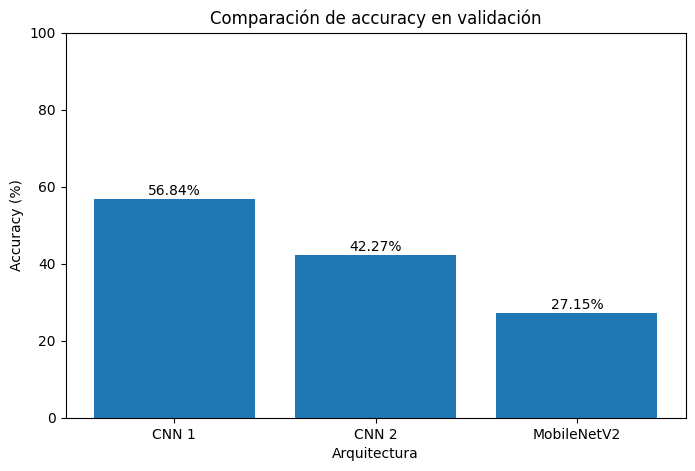

In [24]:
import matplotlib.pyplot as plt

modelos = ["CNN 1", "CNN 2", "MobileNetV2"]
accuracy = [56.84, 42.27, 27.15]

plt.figure(figsize=(8, 5))

plt.bar(modelos, accuracy)

plt.title("Comparación de accuracy en validación")
plt.xlabel("Arquitectura")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, valor in enumerate(accuracy):
    plt.text(i, valor + 1, f"{valor:.2f}%", ha="center")

plt.show()

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

En esta actividad se implementaron y evaluaron dos arquitecturas CNN diseñadas desde cero y una arquitectura de Transfer Learning basada en MobileNetV2, utilizando el dataset CIFAR-10 y técnicas de Data Augmentation.

La arquitectura CNN 1 obtuvo el mejor resultado de los experimentos realizados, alcanzando un accuracy de validación de 56.84% después de cinco épocas. Su arquitectura fue relativamente sencilla, pero logró un desempeño adecuado gracias a la utilización de capas convolucionales, MaxPooling y Dropout.

La CNN 2 presentó una arquitectura más profunda, incorporando cinco capas convolucionales, BatchNormalization y Dropout. En la primera época obtuvo un accuracy de validación de 42.27%. Debido a que el modelo fue evaluado después de una sola época, sería necesario realizar un entrenamiento más prolongado para determinar si su mayor profundidad puede mejorar el desempeño respecto a la CNN 1.

Por otra parte, se implementó MobileNetV2 mediante Transfer Learning, utilizando pesos previamente entrenados con ImageNet y un nuevo clasificador para las diez clases de CIFAR-10. En el experimento realizado obtuvo un accuracy de validación de 27.15% después de una época. Este resultado no permite realizar una comparación completamente equivalente con las CNN, debido a que los modelos fueron entrenados bajo diferentes condiciones de cantidad de épocas y datos utilizados.

Considerando los resultados obtenidos, la CNN 1 fue la arquitectura con mayor accuracy de validación dentro de los experimentos realizados. Además, presentó un buen equilibrio entre simplicidad y desempeño. Sin embargo, no se puede afirmar de manera definitiva que sea la mejor arquitectura posible, ya que sería necesario realizar experimentos bajo condiciones iguales de entrenamiento.

Como mejoras futuras, se podría entrenar la CNN 2 durante más épocas y ajustar hiperparámetros como la tasa de aprendizaje, el tamaño del batch y la cantidad de filtros. Para MobileNetV2 se podría realizar fine-tuning de algunas de sus capas superiores y ajustar la arquitectura para las características específicas de CIFAR-10. También sería conveniente utilizar las mismas condiciones de entrenamiento para las tres arquitecturas y así obtener una comparación experimental más justa.
